In [1]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
# custom
import custom.models as mod
import custom.tools as tl

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

h5file= "L1_70_12_6_6.h5"
h5_path = f"/mnt/eph/data/{h5file}"

cuda


# Losses

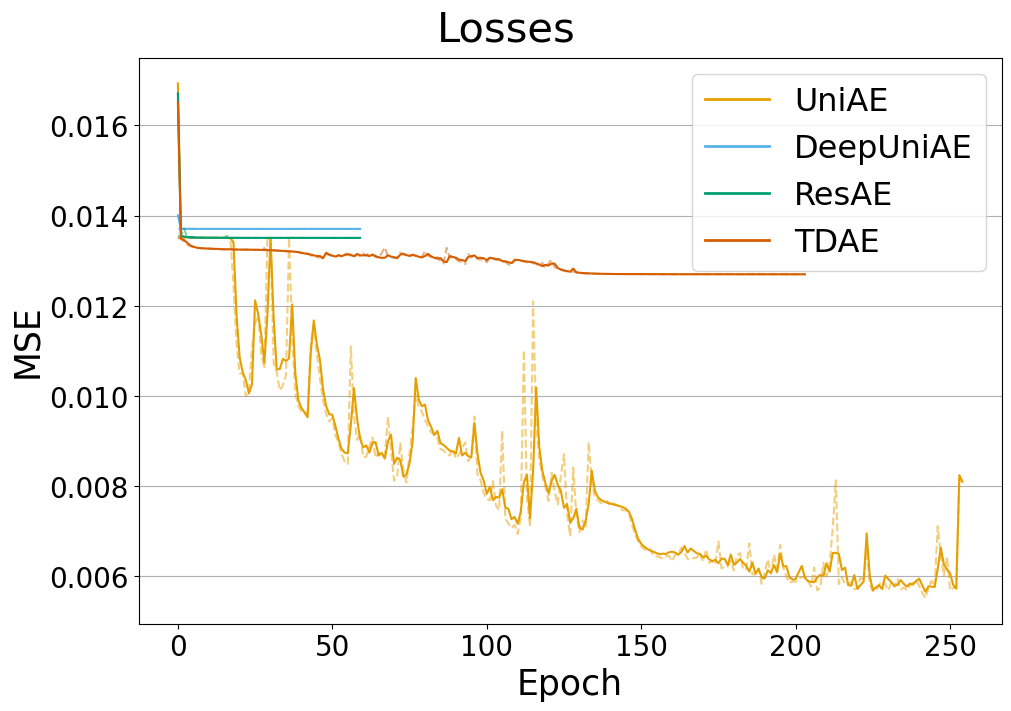

In [26]:
train = {}
val = {}
models = ['UniAE', 'DeepUniAE', 'ResAE']
C = ['#E69F00', '#56B4E9', '#009E73', "#D55E00"]

for loss, model in zip(['/mnt/eph/uni_feat_model_stuff/trial_20/losses_255.pickle',
    '/mnt/eph/deepsea_optune/trial_6/losses_60.pickle',
    '/mnt/eph/resae_optuning/training/losses_60.pickle'
             ], models):
    with open(loss, 'rb') as fin: losses = pickle.load(fin)
    train[model] = losses['train']
    val[model] = losses['val']

models += ['TDAE']
multi = torch.load('/mnt/eph/multi_feat_model_stuff/trials/item2_20_epoch202.pt', weights_only=False)
train['TDAE'] = multi['losses']['train']
val['TDAE'] = multi['losses']['val']

train['DeepUniAE'] = [loss + .0002 for loss in train['DeepUniAE']]
val['DeepUniAE'] = [loss + .0002 for loss in val['DeepUniAE']]

fig, ax = plt.subplots(figsize=(10,7), layout='constrained')
fig.suptitle(f'Losses', fontsize=30)
for i, model in enumerate(models):
    ax.plot(train[model], c=C[i], label=model)
    ax.plot(val[model], c=C[i], ls='--', alpha=.5)
    

ax.set_xlabel('Epoch', fontsize=25)
ax.set_ylabel('MSE', fontsize=25)
ax.tick_params(labelsize=20)
ax.grid(which='both', axis='y')
leg = ax.legend(fontsize=23)
for line in leg.get_lines(): line.set_linewidth(2)
# plt.savefig('/mnt/eph/report_figures/losses.pdf')  ######### DANGER ZONE #########
plt.show()

# Reconstruction

In [5]:
win_len_uni = 100
win_stride_uni = 60
win_len_multi = 48
win_stride_multi = 42

batch_size = 1
num_workers = 1
persistent_workers = False

runs = {'UniAE': {'model': mod.LSTMAEUni(),
                  'path': '/mnt/eph/uni_feat_model_stuff/trial_20/mod_opt_scal_235.pt'},
        'DeepUniAE': {'model': mod.DeepAE(h_s1=128, n_l1=2, h_s2=32, n_l2=2, h_s3=8, n_l3=3, dropout=.5, reg=False),
                      'path': '/mnt/eph/deepsea_optune/trial_6/mod_opt_scal_60.pt'},
        'ResAE': {'model': mod.ResAE(dropout=.25, reg=False),
                  'path': '/mnt/eph/resae_optuning/training/mod_opt_scal_60.pt'},
        'TDAE': {'model': mod.AEric2(sq_len=389, num_feat=48, exp_dim=768, compr_dim=192, num_layers=2),
                 'path': '/mnt/eph/multi_feat_model_stuff/trials/item2_20_epoch202.pt'},
        }
         

test_uni = tl.h5set(h5_path, win_len=win_len_uni, win_stride=win_stride_uni, name='C')
test_multi = tl.h5set(h5_path, win_len=win_len_multi, win_stride=win_stride_multi, name='C')

test_loader_uni = DataLoader(test_uni, batch_size=batch_size, shuffle=False, pin_memory=False, num_workers=num_workers, persistent_workers=persistent_workers, drop_last=True)
test_loader_multi = DataLoader(test_multi, batch_size=batch_size, shuffle=False, pin_memory=False, num_workers=num_workers, persistent_workers=persistent_workers, drop_last=True)

sample_uni = next(iter(test_loader_uni)).reshape(-1, win_len_uni, 1).to(device)  # WARNING only if batch_size=1
sample_multi = next(iter(test_loader_multi)).to(device)
print(sample_uni.shape)
print(sample_multi.shape)
del test_loader_uni, test_loader_multi


out = {'UniAE': {'zorder': 2.01, 'C': '#E69F00'},
       'DeepUniAE': {'zorder': 2.03, 'C': '#56B4E9'},
       'ResAE': {'zorder': 2.04, 'C': '#009E73'},
       'TDAE': {'zorder': 2.02, 'C': '#D55E00'}
      }
for key, item in runs.items():
    print(key)
    model = torch.compile(item['model'].to(device))
    model.load_state_dict(torch.load(item['path'])['model_state_dict'])
    model.eval()
    with torch.no_grad():
        with torch.autocast(device_type=str(device), dtype=torch.float16):
            if key != 'TDAE':
                mod_out = model(sample_uni)
                print(f"{mod_out.shape=}")
                mod_out = torch.hstack([mod_out[0, :, 0]] + [mod_out[i, -win_stride_uni:, 0] for i in range(1, mod_out.shape[0])]).to('cpu')
                print(f"{mod_out.shape=}")
            else:
                mod_out = model(sample_multi)
                print(f"{mod_out.shape=}")
                mod_out = torch.hstack([mod_out[0, 0, :]] + [mod_out[0, i, -win_stride_multi:] for i in range(1, mod_out.shape[1])]).to('cpu')
                print(f"{mod_out.shape=}")
            out[key]['rec'] = mod_out
del runs, model

torch.Size([272, 100, 1])
torch.Size([1, 389, 48])
UniAE
mod_out.shape=torch.Size([272, 100, 1])
mod_out.shape=torch.Size([16360])
DeepUniAE
mod_out.shape=torch.Size([272, 100, 1])
mod_out.shape=torch.Size([16360])
ResAE
mod_out.shape=torch.Size([272, 100, 1])
mod_out.shape=torch.Size([16360])
TDAE
mod_out.shape=torch.Size([1, 389, 48])
mod_out.shape=torch.Size([16344])


In [ ]:
## offset DeepUniAE to avoid overlap
# out['DeepUniAE']['rec'] = [val + .01 for val in out['DeepUniAE']['rec']]

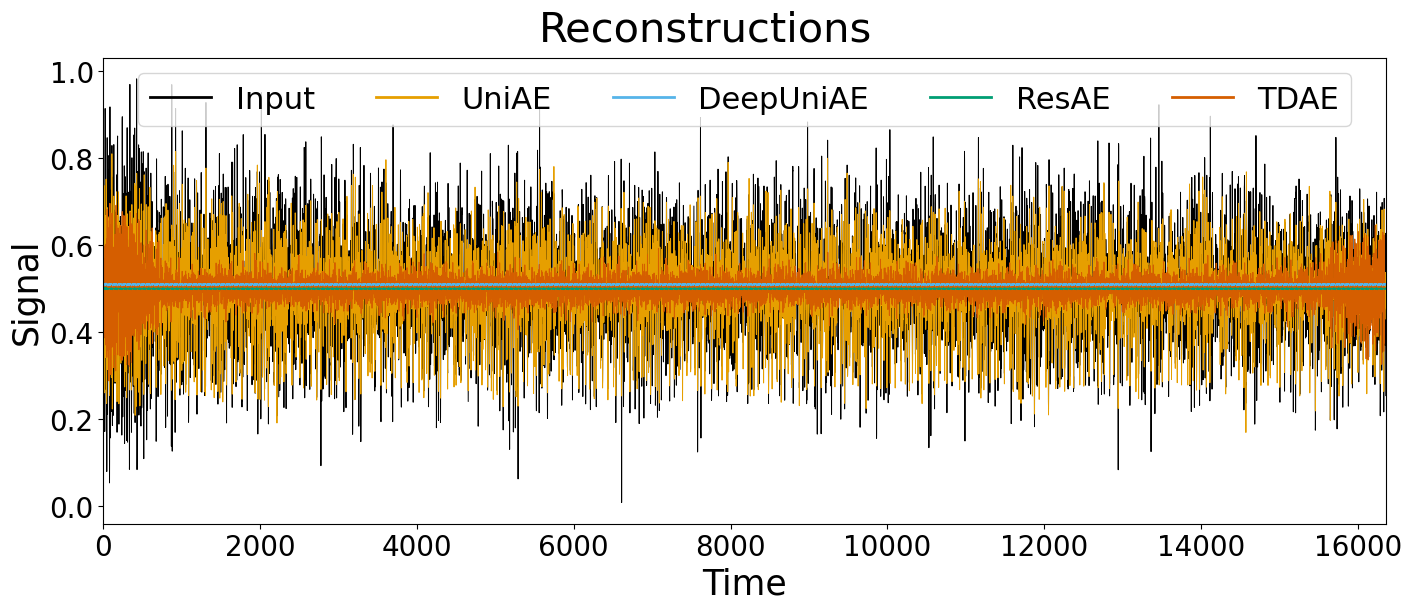

In [33]:
inp = torch.hstack([sample_uni[0, :, 0]] + [sample_uni[i, -win_stride_uni:, 0] for i in range(1, sample_uni.shape[0])]).to('cpu')

fig, ax = plt.subplots(figsize=(14, 6), layout='constrained')
fig.suptitle('Reconstructions', fontsize=30)

ax.plot(inp, c='k', lw=.7, label='Input')
for key, item in out.items():
    ax.plot(item['rec'], c=item['C'], lw=.7, label=key, zorder=item['zorder'])
    
ax.set_xlim(0, len(inp))
leg = ax.legend(loc='upper center', ncols=5, fontsize=22, markerscale=3)
for line in leg.get_lines(): line.set_linewidth(2)
ax.set_xlabel('Time', fontsize=25)
ax.set_ylabel('Signal', fontsize=25)
ax.tick_params(labelsize=20)
# plt.savefig('/mnt/eph/report_figures/reconstructions.pdf')  ######### DANGER ZONE #########
plt.show()

# Anomaly Detection

In [2]:
win_len_uni = 100
win_stride_uni = 60

batch_size = 1
num_workers = 6
persistent_workers = False

weights = torch.load('/mnt/eph/uni_feat_model_stuff/trial_20/mod_opt_scal_235.pt')['model_state_dict']
model = torch.compile(mod.LSTMAEUni().to(device))
model.load_state_dict(weights)
test_uni = tl.h5set(h5_path, win_len=win_len_uni, win_stride=win_stride_uni, name='C')
test_loader_uni = DataLoader(test_uni, batch_size=batch_size, shuffle=False, pin_memory=False, num_workers=num_workers, persistent_workers=persistent_workers, drop_last=True)

loss_ew = nn.MSELoss(reduction='none')
test_loss = []
model.eval()
with torch.no_grad():
    for batch_data in tqdm(test_loader_uni):
        batch_data = batch_data.reshape(-1, 100, 1).to(device)
        with torch.autocast(device_type='cuda', dtype=torch.float16): out = model(batch_data)
        ew_loss = loss_ew(out, batch_data)
        ew_loss = ew_loss.mean(dim=1)
        test_loss.append(ew_loss.squeeze(-1))
grid = torch.vstack(test_loss).cpu().numpy()

thresh = np.linspace(.013, .02, 1000)
prec = []
rec = []
for i in thresh:
    testing = np.any(grid > i, axis=1)
    fp = np.sum(testing[:3000])
    tp = np.sum(testing[-3000:])
    prec.append(tp / (tp + fp))
    rec.append(tp / 3000)

100%|███████████████████████████████████████████████████████████████████| 12000/12000 [03:39<00:00, 54.60it/s]


In [3]:
besthr_idx = np.argmax(np.array(rec) < .75)
print(besthr_idx)
print(rec[besthr_idx], prec[besthr_idx])

173
0.7496666666666667 0.6278615298715802


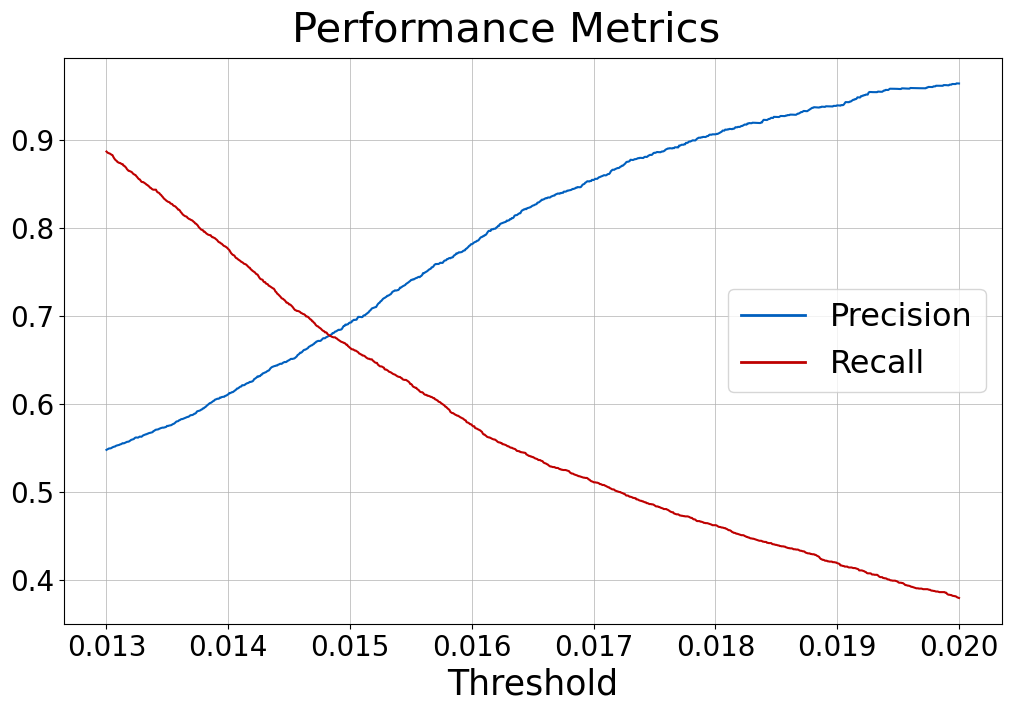

In [96]:
fig, ax = plt.subplots(figsize=(10,7), layout='constrained')
fig.suptitle(f'Performance Metrics', fontsize=30)
ax.plot(thresh, prec, c='#005fbe', label='Precision')
ax.plot(thresh, rec, c='#be0000', label='Recall')
ax.grid(lw=.5)
ax.set_axisbelow(True)
ax.set_xlabel('Threshold', fontsize=25)
ax.tick_params(labelsize=20)
leg = ax.legend(loc='center right', fontsize=23)
for line in leg.get_lines(): line.set_linewidth(2)
# plt.savefig('../scores.pdf')  ######### DANGER ZONE #########
plt.show()

In [4]:
testing = np.any(grid > thresh[besthr_idx], axis=1)
fp = np.sum(testing[3000:6000])
tp = np.sum(testing[6000:-3000])
print(tp / (tp + fp))
print(tp / 3000)

0.6368684064408662
0.7646666666666667


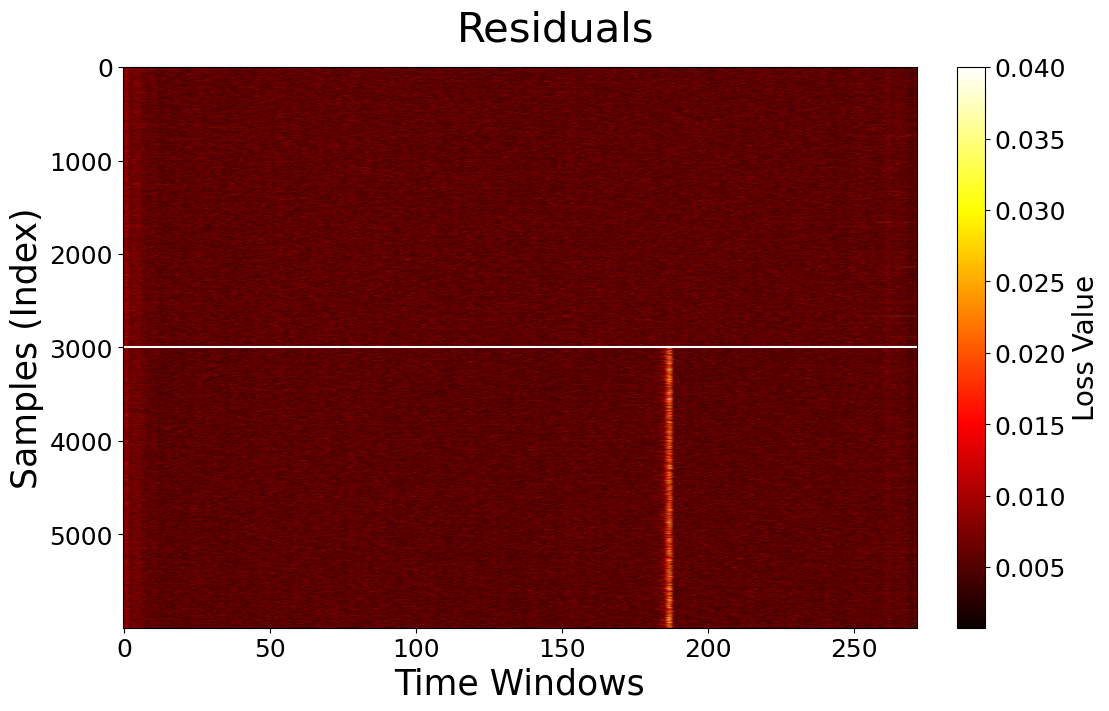

In [6]:
fig, ax = plt.subplots(figsize=(11,7), layout='constrained')
fig.suptitle('Residuals', fontsize=30)
im = ax.imshow(grid[3000:-3000], cmap='hot', aspect='auto', interpolation='lanczos', vmax=.04)
cbar = fig.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=18)
cbar.ax.set_ylabel('Loss Value', fontsize=20)
ax.set_xlabel('Time Windows', fontsize=25)
ax.set_ylabel('Samples (Index)', fontsize=25)
ax.axhline(3000, c='white')
ax.tick_params(labelsize=18)
# plt.savefig('../heatmap.pdf')  ######### DANGER ZONE #########
plt.show()

# Appendix: regularized TDAE
Below are the results of the last attempt we made at using the regularized loss function on the TDAE model. While the reconstruction is better than the one shown in the graphics above for the unregularized model, it is unclear whether this is due to the regularization term, or the different hypeparameters, especially window length, and stride. Further work should be done to assess this possibility, and hence has not been discussed in the report.

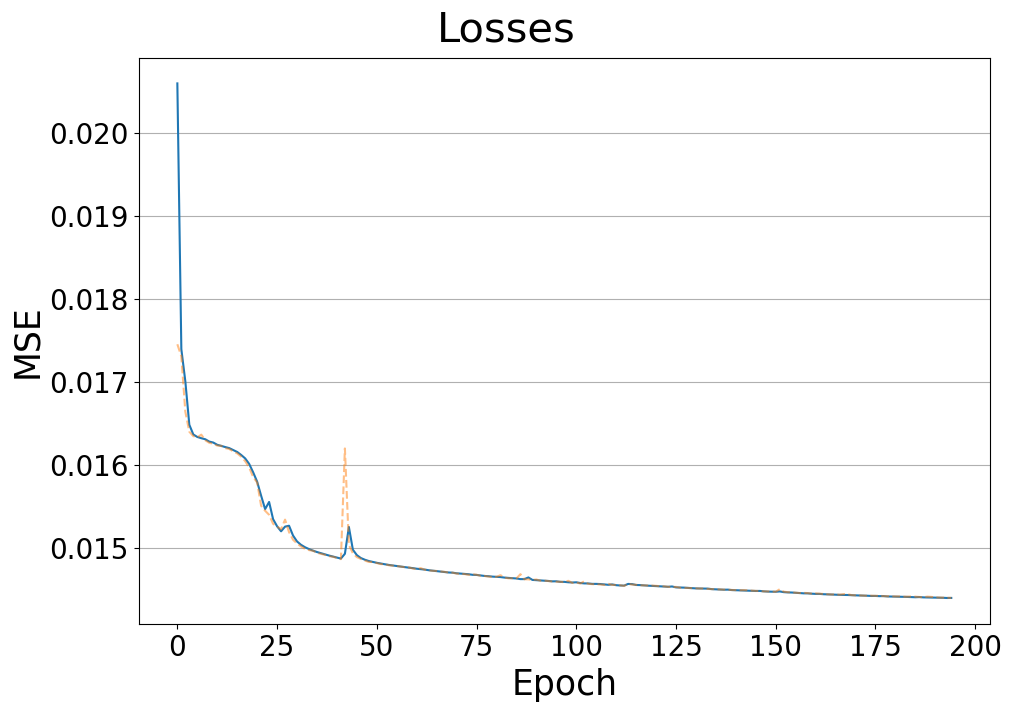

In [11]:
train = {}
val = {}
multi = torch.load('/mnt/eph/multi_feat_model_stuff/trials/aeribella_5_epoch193.pt', weights_only=False)
train['TDAE'] = multi['losses']['train']
val['TDAE'] = multi['losses']['val']

fig, ax = plt.subplots(figsize=(10,7), layout='constrained')
fig.suptitle(f'Losses', fontsize=30)
ax.plot(train['TDAE'])
ax.plot(val['TDAE'], ls='--', alpha=.5)
ax.set_xlabel('Epoch', fontsize=25)
ax.set_ylabel('MSE', fontsize=25)
ax.tick_params(labelsize=20)
ax.grid(which='both', axis='y')
for line in leg.get_lines(): line.set_linewidth(2)
# plt.savefig('/mnt/eph/report_figures/losses.pdf')  ######### DANGER ZONE #########
plt.show()

In [21]:
win_len_multi = 72
win_stride_multi = 63

batch_size = 1
num_workers = 1
persistent_workers = False

runs = {
        'TDAE': {'model': mod.AEric2(sq_len=259, num_feat=72, exp_dim=6*72, compr_dim=2*72, num_layers=2),
                 'path': '/mnt/eph/multi_feat_model_stuff/trials/aeribella_5_epoch193.pt'},
        }
         

test_multi = tl.h5set(h5_path, win_len=win_len_multi, win_stride=win_stride_multi, name='C')

test_loader_multi = DataLoader(test_multi, batch_size=batch_size, shuffle=False, pin_memory=False, num_workers=num_workers, persistent_workers=persistent_workers, drop_last=True)

sample_multi = next(iter(test_loader_multi)).to(device)
print(sample_multi.shape)
del test_loader_multi


out = {'UniAE': {'zorder': 2.01, 'C': '#E69F00'},
       'DeepUniAE': {'zorder': 2.03, 'C': '#56B4E9'},
       'ResAE': {'zorder': 2.04, 'C': '#009E73'},
       'TDAE': {'zorder': 2.02, 'C': '#D55E00'}
      }
for key, item in runs.items():
    print(key)
    model = torch.compile(item['model'].to(device))
    model.load_state_dict(torch.load(item['path'])['model_state_dict'])
    model.eval()
    with torch.no_grad():
        with torch.autocast(device_type=str(device), dtype=torch.float16):
            if key != 'TDAE':
                mod_out = model(sample_uni)
                print(f"{mod_out.shape=}")
                mod_out = torch.hstack([mod_out[0, :, 0]] + [mod_out[i, -win_stride_uni:, 0] for i in range(1, mod_out.shape[0])]).to('cpu')
                print(f"{mod_out.shape=}")
            else:
                mod_out = model(sample_multi)
                print(f"{mod_out.shape=}")
                mod_out = torch.hstack([mod_out[0, 0, :]] + [mod_out[0, i, -win_stride_multi:] for i in range(1, mod_out.shape[1])]).to('cpu')
                print(f"{mod_out.shape=}")
            out[key]['rec'] = mod_out
del runs, model

torch.Size([1, 259, 72])
TDAE
mod_out.shape=torch.Size([1, 259, 72])
mod_out.shape=torch.Size([16326])


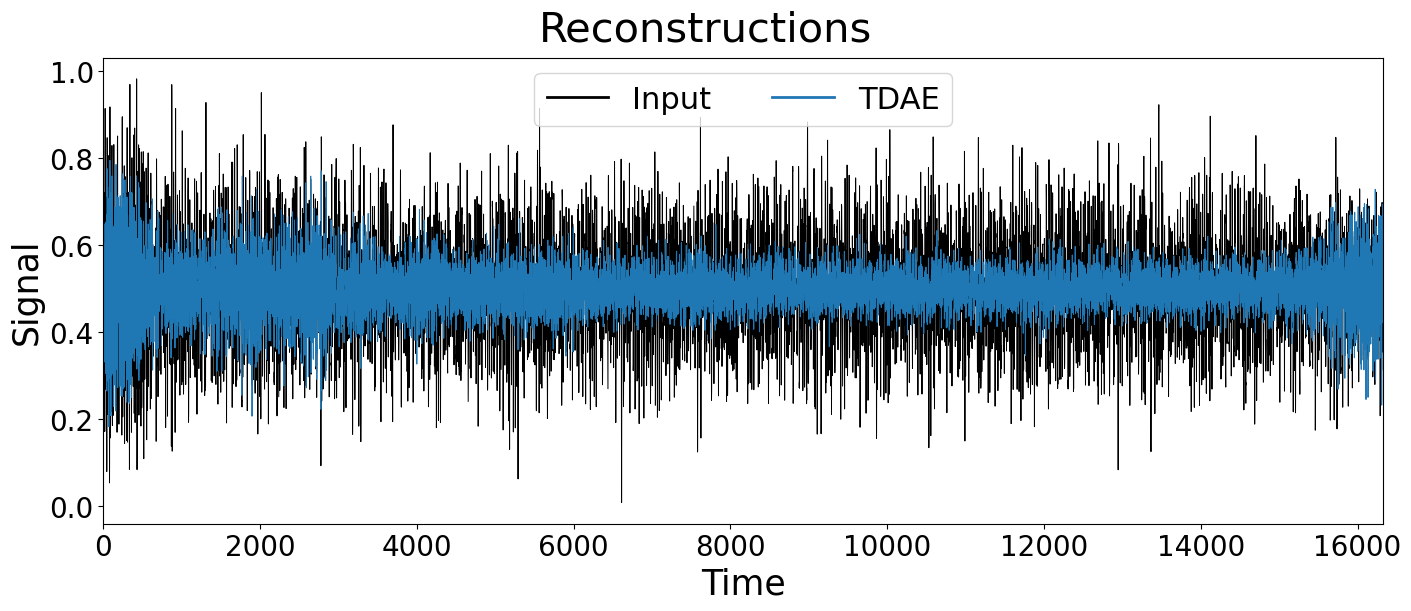

In [27]:
inp = torch.hstack([sample_multi[0, 0, :]] + [sample_multi[0, i, -win_stride_multi:] for i in range(1, sample_multi.shape[1])]).to('cpu')

fig, ax = plt.subplots(figsize=(14, 6), layout='constrained')
fig.suptitle('Reconstructions', fontsize=30)

ax.plot(inp, c='k', lw=.7, label='Input')
ax.plot(out['TDAE']['rec'], lw=.7, label='TDAE', zorder=2.02)
    
ax.set_xlim(0, len(inp))
leg = ax.legend(loc='upper center', ncols=5, fontsize=22, markerscale=3)
for line in leg.get_lines(): line.set_linewidth(2)
ax.set_xlabel('Time', fontsize=25)
ax.set_ylabel('Signal', fontsize=25)
ax.tick_params(labelsize=20)
# plt.savefig('/mnt/eph/report_figures/reconstructions.pdf')  ######### DANGER ZONE #########
plt.show()